In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

 Se trata de un caso real de un punto de venta de una empresa de distribución de productos para el automóvil. La información que se proporciona en los ficheros es de 1000 productos anonimizados por motivos de confidencialidad.

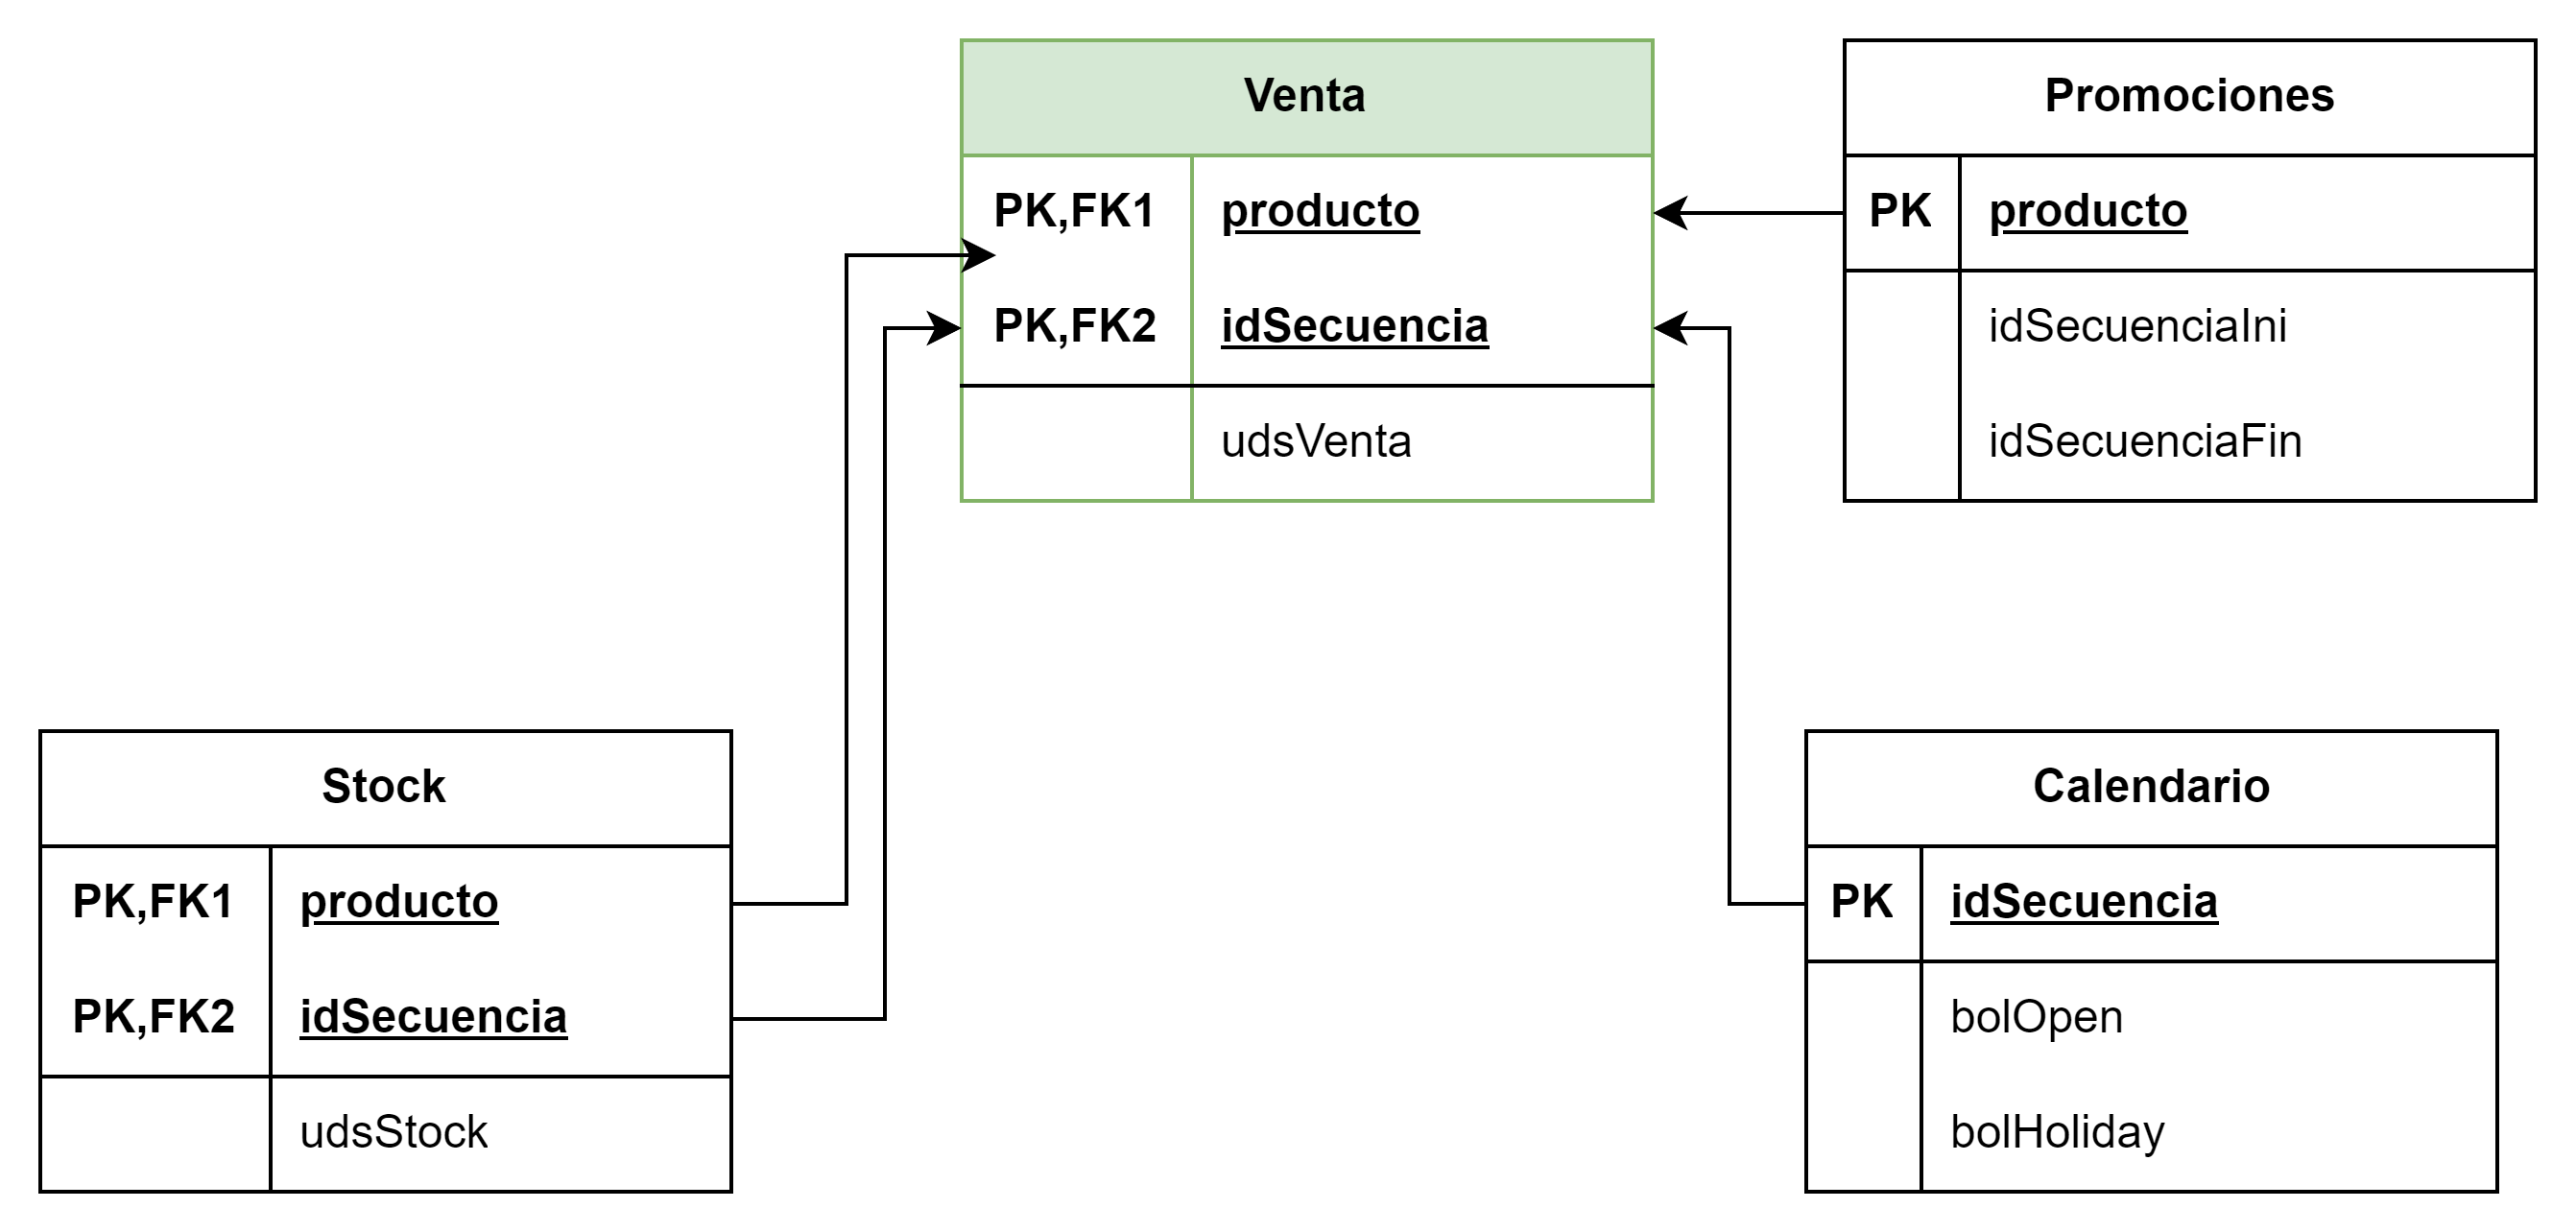

In [2]:
df_venta = pd.read_excel('../Data/Datos.xlsx', sheet_name='Venta')
df_calendario = pd.read_excel('../Data/Datos.xlsx', sheet_name='Calendario')
df_promociones = pd.read_excel('../Data/Datos.xlsx', sheet_name='Promociones')
df_stock = pd.read_excel('../Data/Datos.xlsx', sheet_name='Stock')

# Ventas

## Comprobacion valores nulos y tipo de variable

In [3]:
df_venta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629391 entries, 0 to 629390
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   producto     629391 non-null  int64
 1   idSecuencia  629391 non-null  int64
 2   udsVenta     629391 non-null  int64
dtypes: int64(3)
memory usage: 14.4 MB


Se cuenta con los siguientes datos:

- `producto`: identificador único del anuncio. Se cuenta con mil productos: [1,1000]
- `idSecuencia`: fecha de venta.
- `udsVenta`: unidades vendidas.

En total, el conjunto cuenta con 629391 registros , no se aprecian valores nulos

## Decripcion estadistica de las variables

In [4]:
## Convertir el id de la secuencia en un datetime
df_venta['fecha'] = pd.to_datetime(df_venta['idSecuencia'], format='%Y%m%d')

In [5]:
df_venta.describe()

,producto,idSecuencia,udsVenta,fecha
count,629391.000000,6.293910e+05,629391.000000,629391
mean,500.954704,2.024788e+07,1.187322,2025-03-21 23:59:59.999999744
min,1.000000,2.024032e+07,0.000000,2024-03-22 00:00:00
25%,244.000000,2.024092e+07,0.000000,2024-09-20 00:00:00
50%,506.000000,2.025032e+07,0.000000,2025-03-22 00:00:00
75%,751.000000,2.025092e+07,2.000000,2025-09-21 00:00:00
max,1000.000000,2.026032e+07,397.000000,2026-03-22 00:00:00
std,292.341475,6.351735e+03,2.224450,NaN


Las fechas de venta comprenden desde el 2024-03-22 hasta el 2026-03-22

## Evolucion de las ventas diarias

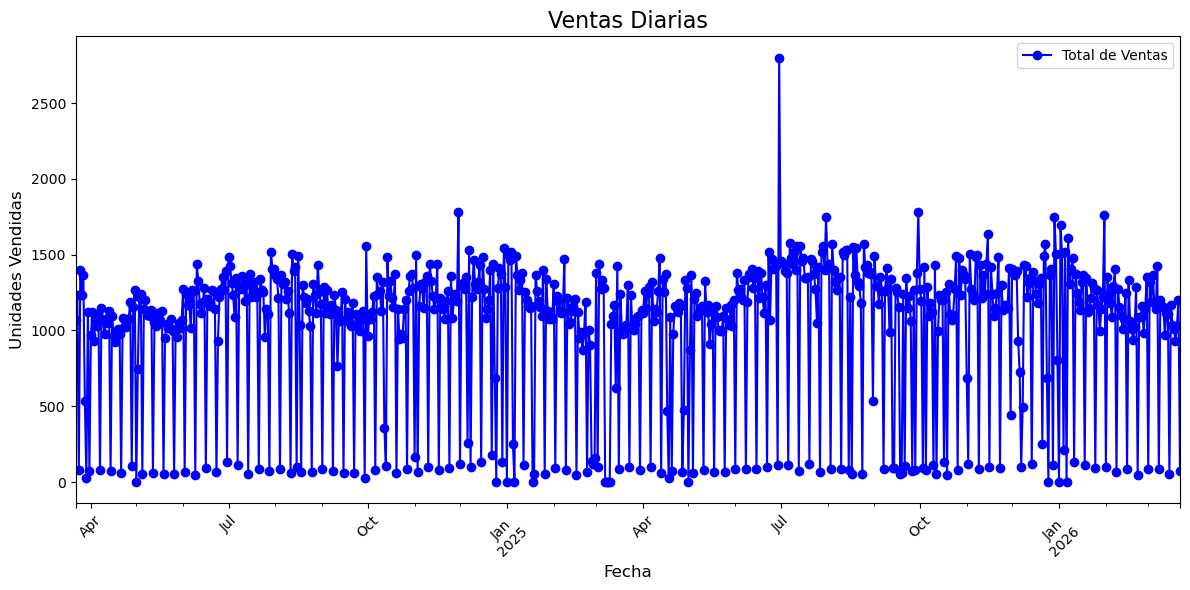

In [8]:
ventas_diarias = df_venta.groupby('fecha')['udsVenta'].sum()

# Graficar serie temporal
ax = ventas_diarias.plot(figsize=(12,6), color='blue', marker='o')

# Títulos y etiquetas
ax.set_title('Ventas Diarias', fontsize=16)
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Unidades Vendidas', fontsize=12)

# Leyenda
ax.legend(['Total de Ventas'])

# Mejorar formato de fechas en eje X
plt.xticks(rotation=45)
plt.tight_layout()  # Ajusta márgenes automáticamente

plt.show()

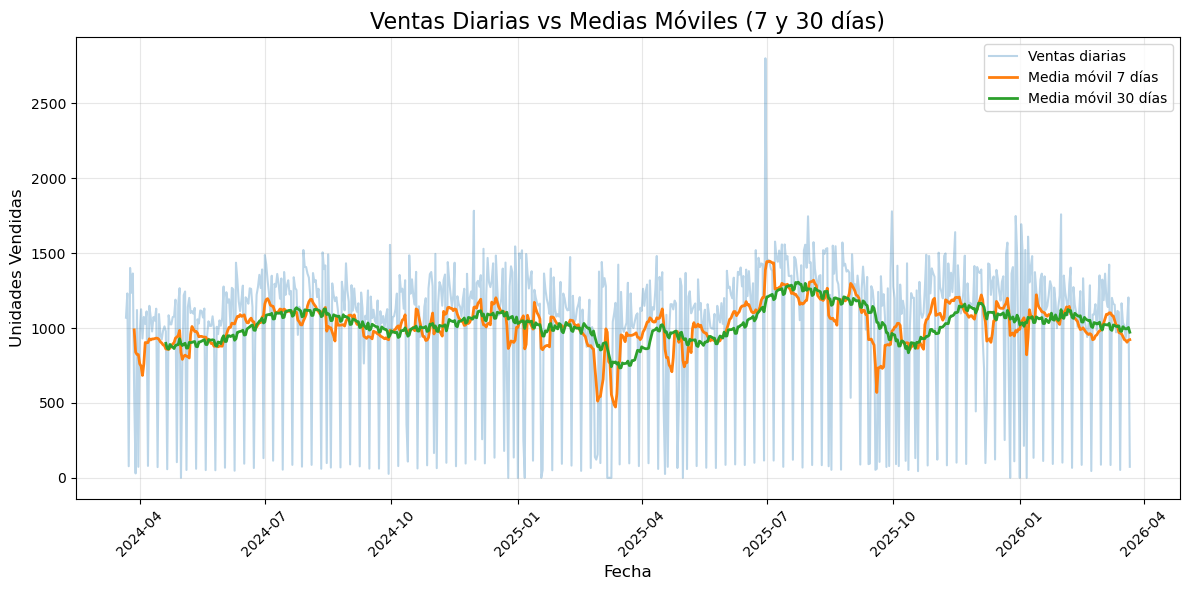

In [19]:
# Medias móviles
ventas_roll_7 = ventas_diarias.rolling(window=7).mean()
ventas_roll_30 = ventas_diarias.rolling(window=30).mean()

# Gráfico
plt.figure(figsize=(12,6))

# Serie original
plt.plot(ventas_diarias, label='Ventas diarias', alpha=0.3)

# Media móvil semanal
plt.plot(ventas_roll_7, label='Media móvil 7 días', linewidth=2)

# Media móvil mensual
plt.plot(ventas_roll_30, label='Media móvil 30 días', linewidth=2)

# Etiquetas
plt.title('Ventas Diarias vs Medias Móviles (7 y 30 días)', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Unidades Vendidas', fontsize=12)

plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

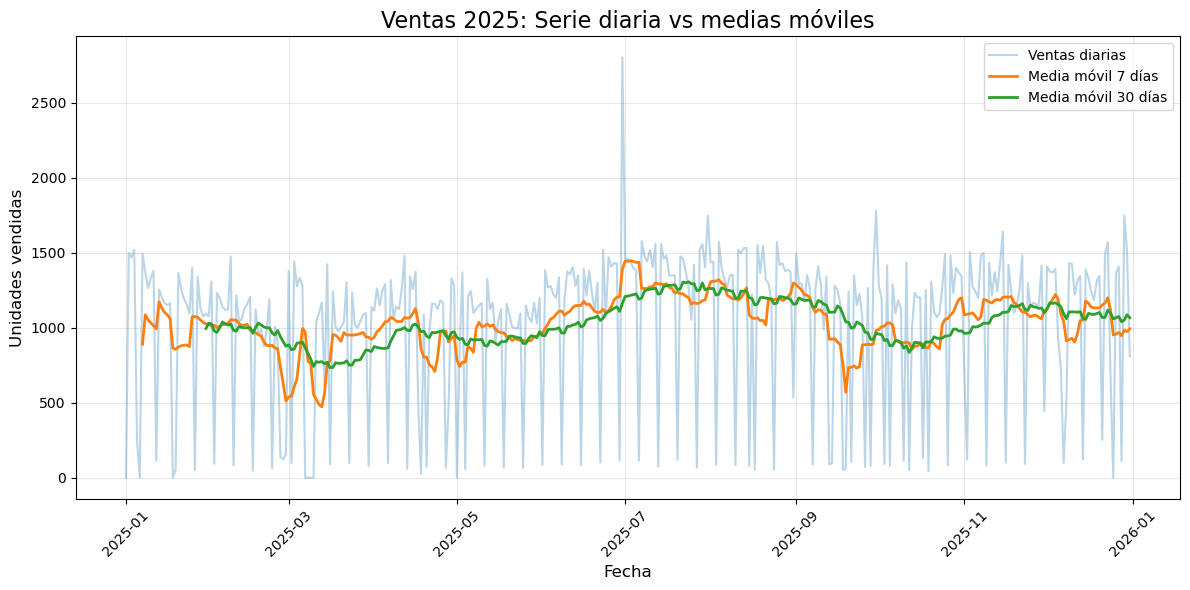

In [18]:
## Ventana 2025
ventas_2025 = (
    df_venta[
        df_venta['fecha'].between('2025-01-01', '2025-12-31')
    ]
    .groupby('fecha')['udsVenta']
    .sum()
)

# Medias móviles
ventas_2025_roll_7 = ventas_2025.rolling(window=7).mean()
ventas_2025_roll_30 = ventas_2025.rolling(window=30).mean()

# Gráfico
plt.figure(figsize=(12,6))

# Serie original
plt.plot(ventas_2025, label='Ventas diarias', alpha=0.3)

# Media móvil semanal
plt.plot(ventas_2025_roll_7, label='Media móvil 7 días', linewidth=2)

# Media móvil mensual
plt.plot(ventas_2025_roll_30, label='Media móvil 30 días', linewidth=2)

# Etiquetas
plt.title('Ventas 2025: Serie diaria vs medias móviles', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Unidades vendidas', fontsize=12)

plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()


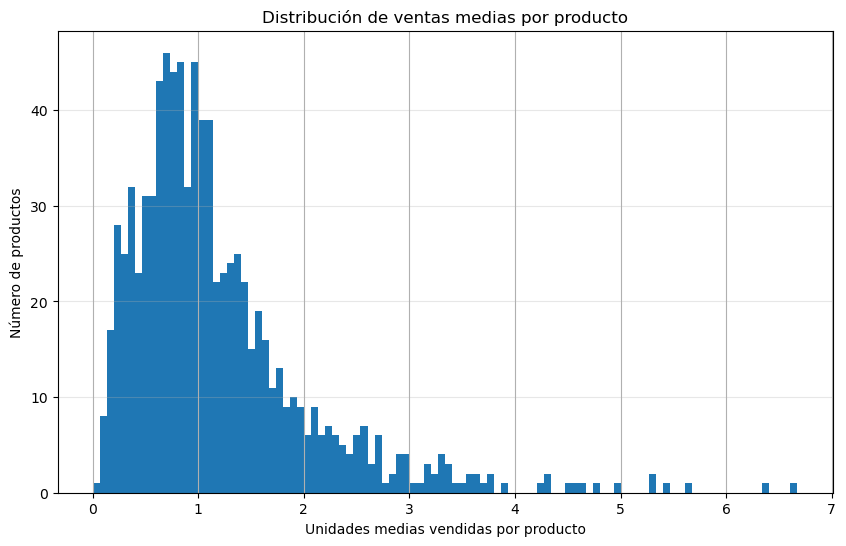

In [20]:
medias = df_venta.groupby('producto')['udsVenta'].mean()

plt.figure(figsize=(10,6))
medias.hist(bins=100)

plt.xlabel('Unidades medias vendidas por producto')
plt.ylabel('Número de productos')
plt.title('Distribución de ventas medias por producto')

plt.grid(axis='y', alpha=0.3)

plt.show()

<Axes: xlabel='producto'>

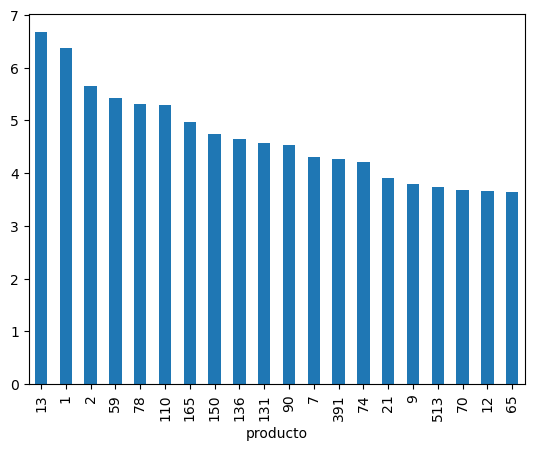

In [21]:
top = medias.sort_values(ascending=False).head(20)

top.plot(kind='bar')

# Calendario

In [ ]:
df_calendario.info()

In [ ]:
df_ventas_full = df_venta.join(df_calendario, how = 'left')